# 5. Analysis of Sales Department Performance: 
Evaluate the effectiveness of individual deal owners and advertising campaigns in terms of the number of 5.1. deals processed, 5.2. conversion rate, and 5.3. total sales amount.

Loading the necessary libraries, loading the deals_clean file, checking data types

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
%matplotlib inline

In [2]:
df_deals = pd.read_pickle("../processed/Deals_clean.pkl")
df_deals.head(3)

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Campaign,SLA,Content,Term,...,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch,SLA_status,level_norm
0,5805028000056864695,Ben Hall,NaT,NaN,New Lead,NaN,03.07.23women,NaT,v16,women,...,2024-06-21 15:30:00,NaN,NaN,NaN,NaN,5805028000056849495,NaN,<NA>,Unknown,<NA>
1,5805028000056859489,Ulysses Adams,NaT,NaN,New Lead,NaN,Unknown,NaT,NaN,NaN,...,2024-06-21 15:23:00,6.0,NaN,0.0,2000.0,5805028000056834471,NaN,<NA>,Unknown,<NA>
2,5805028000056832357,Ulysses Adams,2024-06-21,D - Non Target,Lost,Non target,engwien_AT,0 days 00:26:43,b1-at,21_06_2024,...,2024-06-21 00:00:00,NaN,NaN,NaN,NaN,5805028000056854421,NaN,<NA>,10-30 min,<NA>


In [3]:
df_deals.dtypes

Id                              string
Deal Owner Name                 string
Closing Date            datetime64[ns]
Quality                         object
Stage                           object
Lost Reason                     object
Campaign                        object
SLA                    timedelta64[ns]
Content                         object
Term                            object
Source                          object
Payment Type                    object
Product                         object
Education Type                  object
Created Time            datetime64[ns]
Course duration                float64
Months of study                float64
Initial Amount Paid            float64
Offer Total Amount             float64
Contact Name                    string
City                            object
Level of Deutsch                string
SLA_status                      object
level_norm                      object
dtype: object

Outputting basic statistics for the categorical field "Deal Owner Name".

In [4]:
categorical_stats = df_deals[["Deal Owner Name", "Stage"]].describe()
categorical_stats

,Deal Owner Name,Stage
count,21593,21593
unique,28,13
top,Charlie Davis,Lost
freq,2963,15743


5.1. Calculation late total and paid deals by deal owners ("Deal Owner Name").

In [5]:
total_deals = df_deals.groupby("Deal Owner Name").size().rename("Total Deals")

paid_deals = df_deals[
    (df_deals["Stage"] == "Payment Done") &
    (df_deals["Initial Amount Paid"] >= 100)
    ].groupby("Deal Owner Name").size().rename("Paid Deals")

owner_quality = pd.concat([total_deals, paid_deals], axis=1).fillna(0).reset_index()

owner_quality["Conversion %"] = (owner_quality["Paid Deals"] / owner_quality["Total Deals"] * 100).round(2)

owner_quality = owner_quality.sort_values("Total Deals", ascending=False)
owner_quality

,Deal Owner Name,Total Deals,Paid Deals,Conversion %
5,Charlie Davis,2963,148.0,4.99
12,Julia Nelson,2241,92.0,4.11
21,Ulysses Adams,2165,140.0,6.47
18,Quincy Vincent,1884,65.0,3.45
17,Paula Underwood,1862,93.0,4.99
2,Ben Hall,1345,46.0,3.42
15,Nina Scott,1283,45.0,3.51
23,Victor Barnes,1232,44.0,3.57
4,Cara Iverson,1056,27.0,2.56
6,Diana Evans,1013,1.0,0.10


In [6]:
owner_quality.to_parquet("../processed/parquet/5_owner_quality.parquet", index=False)

Visualisation Total Deals vs Paid Deals per Owner

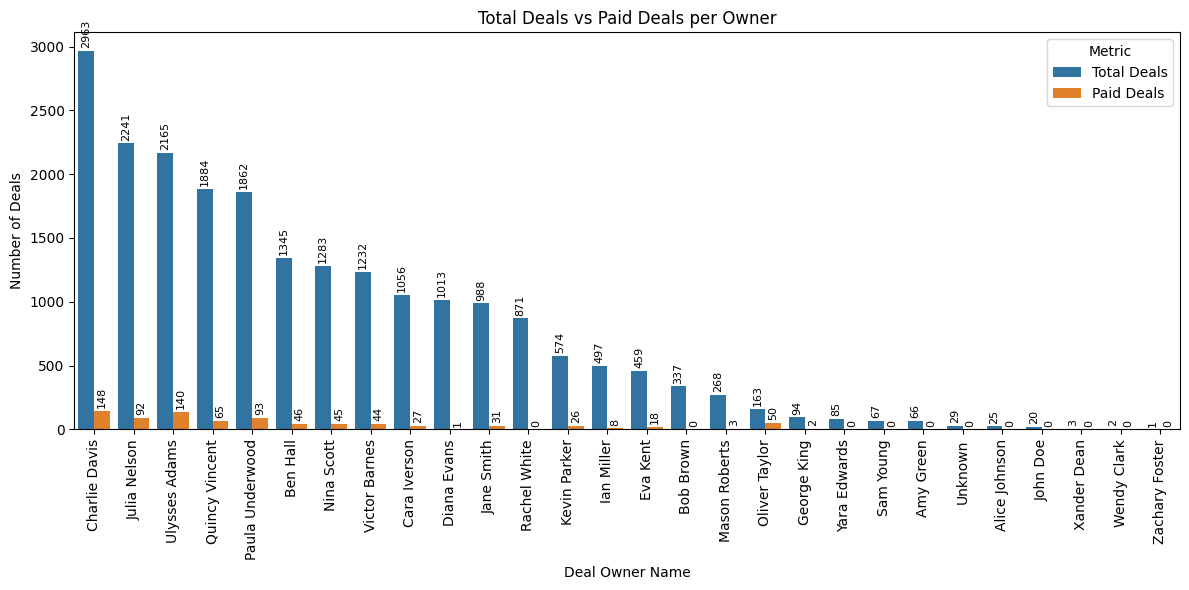

In [7]:
owner_long = owner_quality.melt(id_vars="Deal Owner Name", value_vars=["Total Deals", "Paid Deals"],
     var_name="Metric", value_name="Count")

plt.figure(figsize=(12,6))

ax = sns.barplot(data=owner_long, x="Deal Owner Name", y="Count", hue="Metric", order=owner_quality["Deal Owner Name"])

plt.xticks(rotation=90)
plt.title("Total Deals vs Paid Deals per Owner")
plt.ylabel("Number of Deals")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=8, padding=2, rotation=90)

plt.tight_layout()
plt.show()

5.2. Visualizing conversion rate by deal owners.

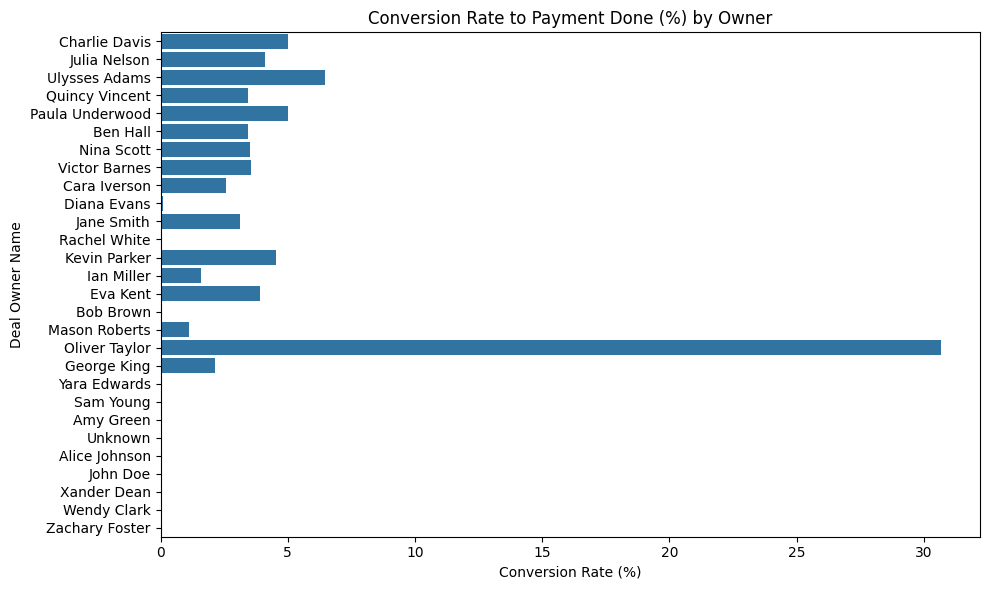

In [8]:
plt.figure(figsize=(10, 6)) 
sns.barplot(
    data=owner_quality,
    y="Deal Owner Name",
    x="Conversion %"
)
plt.title("Conversion Rate to Payment Done (%) by Owner")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Deal Owner Name")
plt.tight_layout()
plt.show()

Conclusion:

The table and charts show a comparison of the total number of deals and the number of paid deals for each manager. shows a comparison of the total number of deals and the number of paid deals for each deal owner.
It is easy to see:
• Which managers handle the highest total volume of deals (Charlie Davis — 2,963 deals);
• Who has the highest number of paid (successful) deals (Charlie Davis — 148, Ulysses Adams — 141);
• The gap between "Total Deals" and "Paid Deals", which reflects work quality / conversion rate for each manager.
For example, a high deal volume does not guarantee high conversion (Charlie Davis — 4.99%), while managers with fewer deals may achieve significantly higher conversion rates (Oliver Taylor — 30.67%).
Thus, the table clearly demonstrates not only productivity but also the effectiveness of each Deal Owner.
This chart shows managers’ effectiveness in terms of money, not just the number of deals. The Money Conversion % metric reflects how much actual paid revenue the company receives from each euro offered to clients. It is a key business indicator that directly impacts revenue, allows comparison of managers regardless of average deal size, highlights strengths and weaknesses in the sales funnel, and identifies who truly generates profit.

5.3 Total sales amount.

Creation a table that shows the manager’s workload, performance, and quality of work through the ratio of paid deals to all processed deals.

In [9]:
valid_sales = (
    (df_deals["Stage"] == "Payment Done") &
    (df_deals["Initial Amount Paid"] >= 100) &
    (df_deals["Months of study"] >= 1) 
)
df_filtered = df_deals[valid_sales].copy()

total_deals = df_deals.groupby("Deal Owner Name").size().rename("Total Deals")

paid_deals = df_filtered.groupby("Deal Owner Name").size().rename("Paid Deals")

total_amount_paid = (
    df_filtered.groupby("Deal Owner Name")["Initial Amount Paid"]
    .sum()
    .rename("Total Amount Paid")
)
offer_total_amount = (
    df_filtered.groupby("Deal Owner Name")["Offer Total Amount"]
    .sum()
    .rename("Offer Total Amount")
)
owner_money_conv = pd.concat(
    [total_deals, paid_deals, total_amount_paid, offer_total_amount], 
    axis=1
).fillna(0).reset_index()

owner_money_conv["Money Conversion %"] = (
    owner_money_conv.apply(
        lambda row: (row["Total Amount Paid"] / row["Offer Total Amount"] * 100) 
        if row["Offer Total Amount"] > 0 else 0, 
        axis=1
    )).round(2)

owner_money_conv["Conversion %"] = (
    owner_money_conv["Paid Deals"] / owner_money_conv["Total Deals"] * 100
).round(2)

owner_money_conv = owner_money_conv.sort_values(
    "Offer Total Amount", 
    ascending=False
).reset_index(drop=True)

owner_money_conv

,Deal Owner Name,Total Deals,Paid Deals,Total Amount Paid,Offer Total Amount,Money Conversion %,Conversion %
0,Charlie Davis,2963,147.0,140450.0,1062600.0,13.22,4.96
1,Ulysses Adams,2165,140.0,126100.0,1011400.0,12.47,6.47
2,Julia Nelson,2241,92.0,84550.0,729700.0,11.59,4.11
3,Paula Underwood,1862,93.0,100650.0,694000.0,14.50,4.99
4,Oliver Taylor,163,50.0,50250.0,524500.0,9.58,30.67
5,Quincy Vincent,1884,65.0,71900.0,465500.0,15.45,3.45
6,Victor Barnes,1232,44.0,46600.0,356000.0,13.09,3.57
7,Ben Hall,1345,46.0,57700.0,345500.0,16.70,3.42
8,Nina Scott,1283,45.0,40600.0,315000.0,12.89,3.51
9,Cara Iverson,1056,27.0,149900.0,220000.0,68.14,2.56


In [10]:
owner_money_conv.to_parquet("../processed/parquet/5_owner_money_conv.parquet", index=False)

In [11]:
print(owner_money_conv.columns)

Index(['Deal Owner Name', 'Total Deals', 'Paid Deals', 'Total Amount Paid',
       'Offer Total Amount', 'Money Conversion %', 'Conversion %'],
      dtype='str')


Total Sales by Manager: Students with 1 Month of Study = Total Amount Paid per Owner

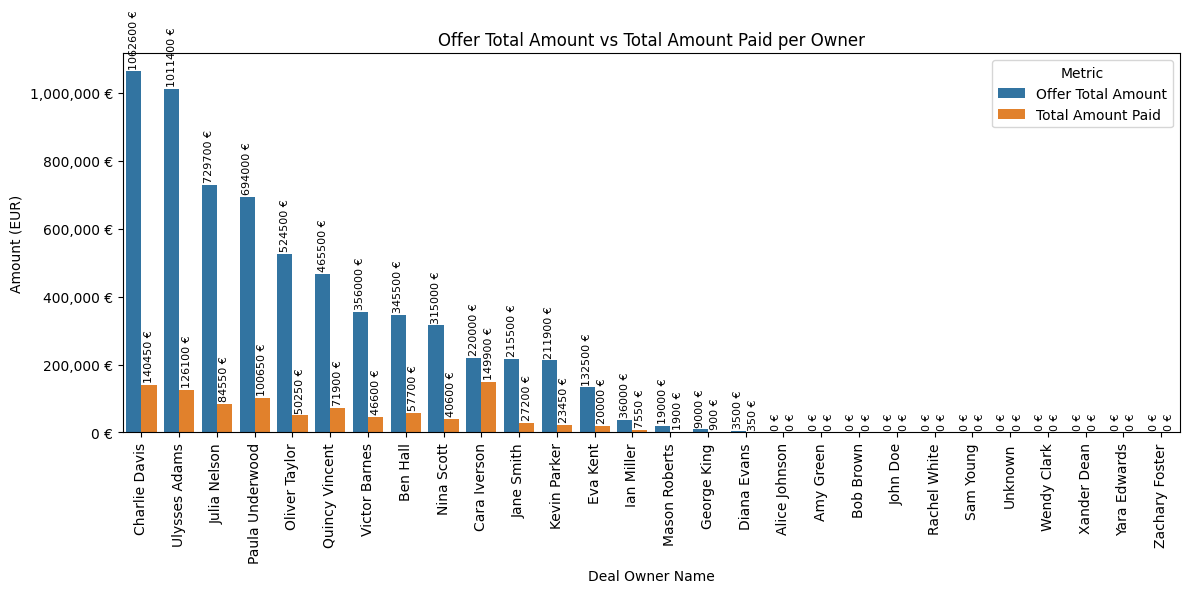

In [12]:
owner_money_long = owner_money_conv.melt(
    id_vars="Deal Owner Name", 
    value_vars=["Offer Total Amount", "Total Amount Paid"],
    var_name="Metric", 
    value_name="Amount"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=owner_money_long, 
    x="Deal Owner Name", 
    y="Amount", 
    hue="Metric", 
    order=owner_money_conv["Deal Owner Name"]
) 

plt.xticks(rotation=90)
plt.title("Offer Total Amount vs Total Amount Paid per Owner")
plt.ylabel("Amount (EUR)")

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f} €'))

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f €", fontsize=8, padding=2, rotation=90)

plt.tight_layout()
plt.show()

Conclusion

Gap Between Offer Total Amount and Actual Payments.

Blue bars (Offer Total Amount) represent the full cost of the educational program (6-11 month programs)
Orange bars (Total Amount Paid) represent actual payments received from students who:
Completed the payment stage (Stage = "Payment Done")
Paid at least €100
Have been studying for at least 1 month
Top Managers by Student Acquisition
Charlie Davis: ~€1.04M — total contract value, ~€140K — already paid
Ulysses Adams: ~€1.01M — total contract value, ~€126K — already paid
Julia Nelson: ~€730K — total contract value, ~€85K — already paid
Paula Underwood: ~€694K — total contract value, ~€100K — already paid
What the Gap Indicates:
Revenue pipeline — money the company will receive over the next 6-11 months
Recent sales — students who just started their programs and made their first payment
Cash flow potential — future revenue streams are visible
Long Tail of Managers
Many managers on the right side of the chart have minimal metrics — these could be new employees or those with few active students.
Recommendation:
The chart shows a healthy pipeline: managers are actively enrolling students in long-term programs. The gap between blue and orange bars is not a conversion problem, but rather deferred revenue that will be collected monthly throughout the duration of the studies.

Distribution of deals by stage and manager

In [13]:
stage_grouped_count = (
    df_deals.groupby("Stage")
    .size()
    .reset_index(name="Deals Count")
    .sort_values("Deals Count", ascending=False))
stage_grouped_count 

,Stage,Deals Count
2,Lost,15743
0,Call Delayed,2248
10,Registered on Webinar,2072
7,Payment Done,858
12,Waiting For Payment,325
8,Qualificated,128
9,Registered on Offline Day,100
5,Need to Call - Sales,33
3,Need To Call,31
11,Test Sent,25


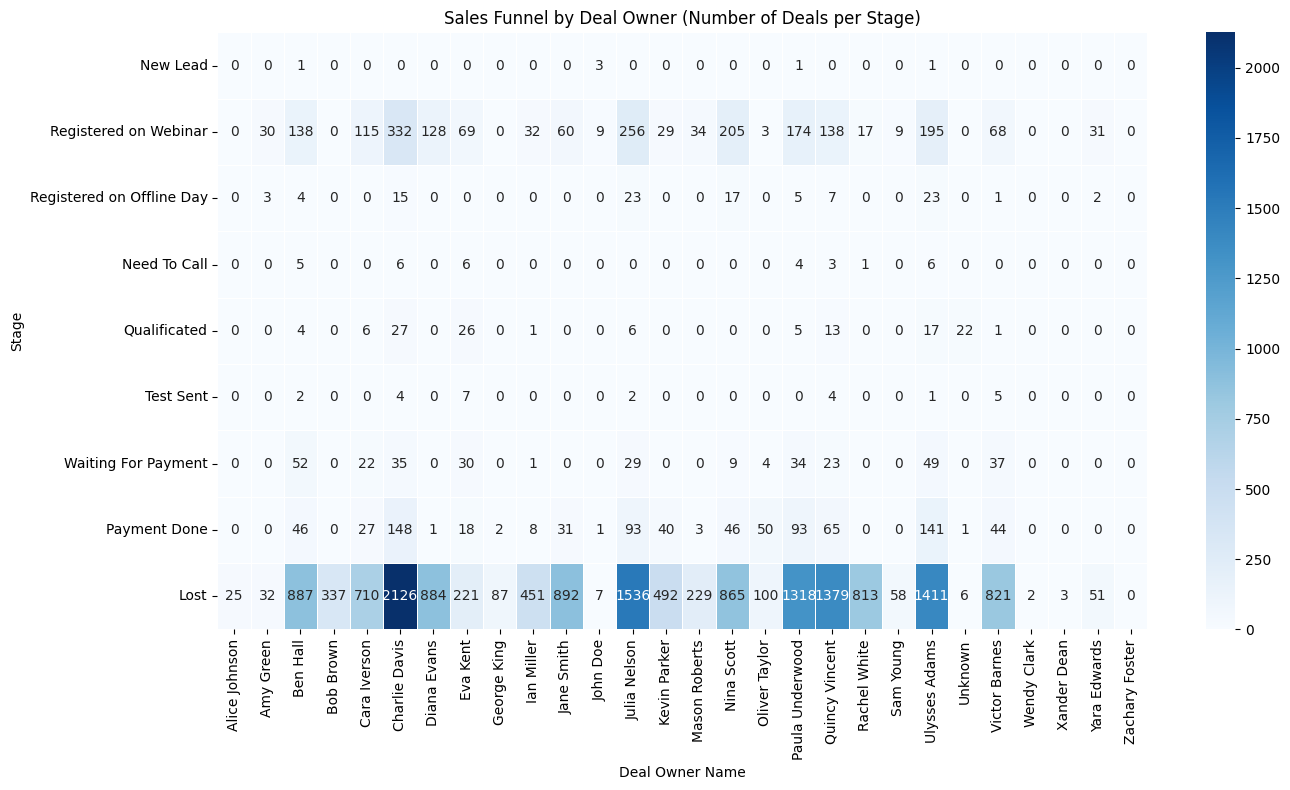

In [14]:
funnel_order = [
    "New Lead",
    "Registered on Webinar",
    "Registered on Offline Day",
    "Need To Call",
    "Qualificated",
    "Test Sent",
    "Waiting For Payment",
    "Payment Done",
    "Lost"
]
funnel_df = (df_deals.groupby(["Deal Owner Name", "Stage"]).size().rename("Count").reset_index())

funnel_pivot = funnel_df.pivot(
    index="Stage", columns="Deal Owner Name", values="Count").fillna(0)

funnel_pivot = funnel_pivot.reindex(funnel_order)

plt.figure(figsize=(14,8))

sns.heatmap(funnel_pivot,cmap="Blues", annot=True, fmt=".0f", linewidths=.5)

plt.title("Sales Funnel by Deal Owner (Number of Deals per Stage)") 
plt.xlabel("Deal Owner Name")
plt.ylabel("Stage")
plt.tight_layout()
plt.show()

In [15]:
funnel_pivot.to_parquet(r"C:\Users\Dell 7530\Documents\ICH\Python for DA\Final project_DA _2026\processed\parquet\5_funnel_pivot.parquet")

# Conclusion.

The heatmap enables quick assessment of: Manager Effectiveness
Who converts leads to payments most effectively (compare columns at "Payment Done" stage).
Who loses deals at mid-funnel stages (bottlenecks at "Need To Call", "Qualificated")
Funnel Bottlenecks.
At which stage deals most frequently stall (horizontal "drops" in color intensity)
Where additional support or automation is needed.
Workload Distribution. How deal volume is distributed across managers.
Identification of overloaded vs. underutilized team members
Lead Quality Indicator. If a manager has many "New Lead" deals but few "Payment Done" — the issue may lie in incoming lead quality rather than sales performance.
